# Appying Data Cleaning and Data Analysis Techniques to a Real World NYC Taxicab Dataset 05/2026

Start by importing pandas in order to convert the parquet file into a readable csv format and load it into a pandas style dataframe.

In [16]:
# imports

import pandas as pd

df = pd.read_parquet('yellow_tripdata_2026-05.parquet')

df.to_csv('yellow_tripdata_2026-05.csv', index=False)



We want to quickly view the shape of the dataset to confirm its dimensions.

In [17]:
df = pd.read_csv('yellow_tripdata_2026-05.csv')

df.shape

C:\Users\david\AppData\Local\Temp\ipykernel_20348\1408930667.py:1: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('yellow_tripdata_2026-05.csv')


(4090836, 20)

Next we want to take a look at the Data Types associated with each feature in the dataset.

In [18]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag           str
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
Airport_fee              float64
cbd_congestion_fee       float64
dtype: object

Taking a look at the head and tail of the dataset will offer us some clues about the quality of the data.

In [19]:
df.head 

df.tail

<bound method NDFrame.tail of          VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               2  2026-05-01 00:04:59   2026-05-01 00:32:48              1.0   
1               2  2026-05-01 00:37:05   2026-05-01 00:59:47              1.0   
2               1  2026-05-01 00:34:05   2026-05-01 00:54:02              1.0   
3               1  2026-05-01 00:55:07   2026-05-01 01:02:43              0.0   
4               7  2026-05-01 00:44:13   2026-05-01 00:44:13              2.0   
...           ...                  ...                   ...              ...   
4090831         2  2026-05-31 23:35:12   2026-05-31 23:51:04              NaN   
4090832         1  2026-05-31 23:48:01   2026-06-01 00:05:57              NaN   
4090833         2  2026-05-31 23:48:50   2026-06-01 00:03:52              NaN   
4090834         2  2026-05-31 23:23:13   2026-05-31 23:38:35              NaN   
4090835         2  2026-05-31 23:41:51   2026-05-31 23:47:32              NaN  

Interestingly, we see that it seems like the bottom half of the data has some NaN values that are fairly consistent. Something that may need to be addressed later.

Check for missing values

In [20]:
print(df.isna().sum())

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          955371
trip_distance                 0
RatecodeID               955371
store_and_fwd_flag       955371
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     955371
Airport_fee              955371
cbd_congestion_fee            0
dtype: int64


Clearly, these NaN values are not random since they appear consistently throughout the dataset the same number of times in each column where the payment type is 0. Upon further reserach we find that in 2018, NYC launches a E-hail and Flex Fare program where users could avoid the metered price by hailing a taxicab ride through an application instead. Since all of these payments were handled through third party taxicab apps such as curb arro etc, they have payment type 0 which indicates its a flex fare trip. It would be bad practice to simply remove all of these columns so we can simply exclude these columns in our final calculations. Here is a visual representation of the relevant features that are tied to payment type:

In [21]:
flex_fare_cols = [
    "passenger_count",
    "RatecodeID",
    "store_and_fwd_flag",
    "congestion_surcharge",
    "Airport_fee"
]

df[flex_fare_cols].isna().groupby(df["payment_type"]).sum()

,passenger_count,RatecodeID,store_and_fwd_flag,congestion_surcharge,Airport_fee
payment_type,,,,,
0,955371,955371,955371,955371,955371
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


Next we find that there are some negative fares which we can deal with by removing those rows.

In [22]:
(df['fare_amount'] <= 0).value_counts()

fare_amount
False    4073654
True       17182
Name: count, dtype: int64

In [23]:
df_clean = df[df['fare_amount'] > 0].copy()

As mentioned above Step 3 should be avoided since NAN values and 0 values have no impact on tip amount.

Proceeding with the tip calculation

1. Start by converting the str datatype that pickup datetime is stored as into a datetime datatype thats easier to parse.

In [24]:
df_clean['tpep_pickup_datetime'] = pd.to_datetime(
    df_clean['tpep_pickup_datetime']
)

2. Extract the hours

In [25]:
df_clean['hour'] = df_clean['tpep_pickup_datetime'].dt.hour

df_clean[['tpep_pickup_datetime', 'hour']].head()

hour_counts = df_clean['hour'].value_counts().sort_index()

display(hour_counts)

hour
0     125155
1      83400
2      56139
3      39269
4      32300
5      36185
6      67316
7     123982
8     160046
9     171280
10    176957
11    191344
12    207051
13    213219
14    236347
15    244557
16    245159
17    274885
18    282499
19    241284
20    219034
21    237900
22    226539
23    181807
Name: count, dtype: int64

3. Calculate the average tip by hour and display the results

In [26]:
avg_tip_by_hour = df_clean.groupby('hour')['tip_amount'].mean()

print(avg_tip_by_hour)

hour
0     2.444058
1     2.126840
2     1.930628
3     1.864874
4     2.099217
5     2.475952
6     2.188714
7     2.315650
8     2.522860
9     2.711376
10    2.953581
11    3.115203
12    3.088717
13    3.279123
14    3.375079
15    3.402845
16    3.560228
17    3.288689
18    3.093504
19    3.176433
20    3.081466
21    3.030759
22    2.899146
23    2.723999
Name: tip_amount, dtype: float64


Observe the Quartiles

In [27]:
import numpy as np

Q1 = df_clean['tip_amount'].quantile(0.25)
Q2 = df_clean['tip_amount'].quantile(0.50)
Q3 = df_clean['tip_amount'].quantile(0.75)

print("Q1",Q1)
print("Q2",Q2)
print("Q3",Q3)

Q1 0.0
Q2 2.25
Q3 4.12


Use the IQR to detect outliers

In [28]:
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

flagged = df_clean[df_clean['tip_amount'] > upper_bound]

print("IQR:", IQR)
print("Upper Bound", upper_bound)

flagged[['fare_amount', 'tip_amount']].sort_values(
    'tip_amount',
    ascending=False
).head(30)

IQR: 4.12
Upper Bound 10.3


,fare_amount,tip_amount
3062240,3.0,239.00
1440039,12.1,222.00
1053686,9.3,220.00
1680917,14.9,200.00
613176,180.8,186.00
1766949,192.7,150.00
3099804,26.8,125.00
2295049,75.1,119.41
303930,380.0,114.30
1050733,352.3,109.95


Lets check for duplicated trip data

In [29]:
print(df_clean.duplicated().sum())

0


There is no duplicated trip data so we can move on to dealing with cash tips

In [30]:
df_clean.groupby('payment_type')['tip_amount'].agg(['count', 'mean'])

,count,mean
payment_type,,
0,954317,0.482394
1,2727212,4.296265
2,368249,0.000366
3,10143,0.001297
4,13733,0.000510


Clearly, these results are consistent with the ones in the Data Cleaning Slides so we will naturally follow the steps to create a new dataset where tips are applicable.

In [33]:
credit_card_only = df_clean[df_clean['payment_type'] == 1]

print(credit_card_only['payment_type'].value_counts())

payment_type
1    2727212
Name: count, dtype: int64


Lets redefine the quartiles in order to see if we find any patterns now that the dataset has changed.

In [34]:
Q1_cc = credit_card_only['tip_amount'].quantile(0.25)
Q2_cc = credit_card_only['tip_amount'].quantile(0.50)
Q3_cc = credit_card_only['tip_amount'].quantile(0.75)

print("Q1",Q1_cc)
print("Q2",Q2_cc)
print("Q3",Q3_cc)

IQR_cc = Q3_cc - Q1_cc

upper_bound_cc = Q3_cc + 1.5 * IQR_cc

flagged_cc = credit_card_only[credit_card_only['tip_amount'] > upper_bound_cc]

print("IQR:", IQR_cc)
print("Upper Bound", upper_bound_cc)

flagged_cc[['fare_amount', 'tip_amount']].sort_values(
    'tip_amount',
    ascending=False
).head(30)


Q1 2.0
Q2 3.3
Q3 5.0
IQR: 3.0
Upper Bound 9.5


,fare_amount,tip_amount
3062240,3.00,239.00
1440039,12.10,222.00
1053686,9.30,220.00
1680917,14.90,200.00
613176,180.80,186.00
1766949,192.70,150.00
3099804,26.80,125.00
2295049,75.10,119.41
303930,380.00,114.30
1050733,352.30,109.95


Recalculate the Average Tip by Hour for the Credit Card only Dataframe

In [39]:
avg_tip_by_hour_cc = credit_card_only.groupby('hour')['tip_amount'].mean()

print(avg_tip_by_hour_cc)

hour
0     4.313469
1     3.853185
2     3.590883
3     3.626157
4     4.441444
5     4.672320
6     3.757090
7     3.615764
8     3.656048
9     3.789554
10    3.986897
11    4.183420
12    4.181395
13    4.410185
14    4.599825
15    4.591052
16    4.760277
17    4.497565
18    4.295883
19    4.345452
20    4.304509
21    4.335144
22    4.433386
23    4.590371
Name: tip_amount, dtype: float64


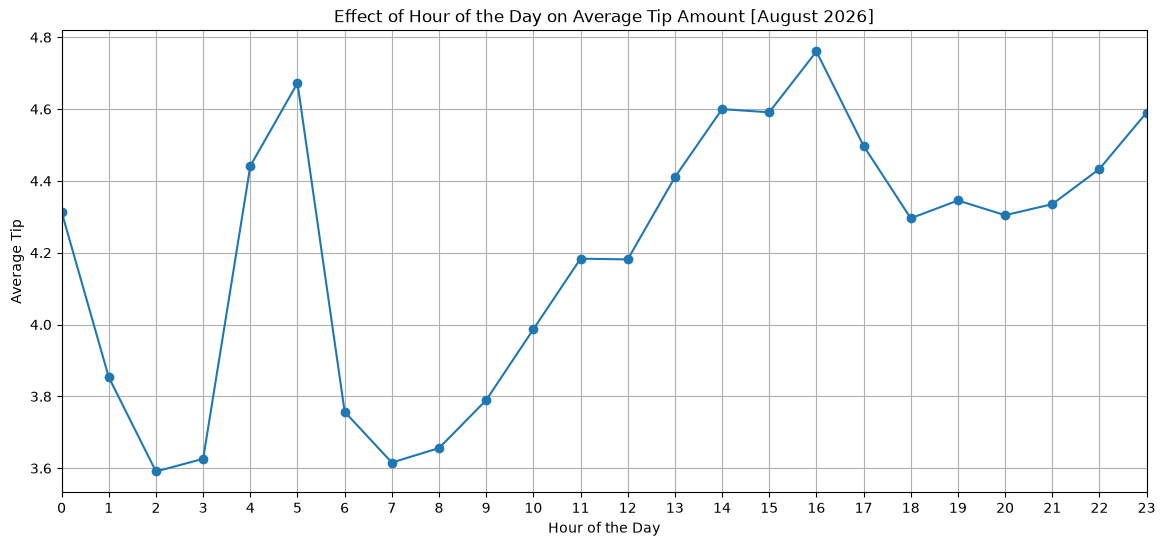

In [49]:
import matplotlib.pyplot as plt

x = avg_tip_by_hour_cc.index

y = avg_tip_by_hour_cc.values

plt.figure(figsize=(14, 6))

plt.plot(x,y, marker = 'o', linestyle = '-')
plt.grid(True)
plt.xlabel("Hour of the Day")
plt.ylabel("Average Tip")
plt.title("Effect of Hour of the Day on Average Tip Amount [August 2026]")
plt.xticks(range(24))
plt.xlim(0, 23)
plt.show()